In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder,LabelEncoder

In [2]:
df = pd.read_csv("vrinda_store_csv.csv")
df.head()

,index,Order ID,Cust ID,Gender,Age,age_group,Date,month,Status,Channel,...,Category,Size,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,B2B
0,1,171-1029312-3038738,1029312,Women,44,adult,04-12-2022,Dec,Delivered,Myntra,...,kurta,XXL,1,INR,376,MOHALI,PUNJAB,140301,IN,False
1,2,405-2183842-2225946,2183842,Women,29,adult,04-12-2022,Dec,Delivered,Ajio,...,Set,L,1,INR,1449,GURUGRAM,HARYANA,122002,IN,False
2,3,171-1641533-8921966,1641533,Women,67,senior,04-12-2022,Dec,Delivered,Myntra,...,Set,S,1,INR,453,KOLKATA,WEST BENGAL,700029,IN,False
3,4,404-7490807-6300351,7490807,Women,20,teenager,04-12-2022,Dec,Delivered,Amazon,...,Set,M,1,INR,729,THANJAVUR,TAMIL NADU,613007,IN,False
4,5,403-9293516-4577154,9293516,Women,62,senior,04-12-2022,Dec,Delivered,Myntra,...,kurta,XXL,1,INR,544,GURUGRAM,HARYANA,122001,IN,False


In [3]:
df.tail()

,index,Order ID,Cust ID,Gender,Age,age_group,Date,month,Status,Channel,...,Category,Size,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,B2B
31042,31043,405-4724097-1016369,4724097,Men,60,adult,06-01-2022,Jan,Delivered,Flipkart,...,kurta,XL,1,INR,565,PUNE,MAHARASHTRA,412307,IN,False
31043,31044,405-4724097-1016369,4724097,Men,34,adult,06-01-2022,Jan,Delivered,Myntra,...,Set,S,1,INR,939,BENGALURU,KARNATAKA,560061,IN,False
31044,31045,408-3572295-5992330,3572295,Men,29,adult,06-01-2022,Jan,Delivered,Amazon,...,Set,L,1,INR,1115,PITHORAGARH,UTTARAKHAND,262501,IN,False
31045,31046,405-1423498-9705162,1423498,Men,46,adult,06-01-2022,Jan,Delivered,Amazon,...,kurta,XL,1,INR,399,DHULE,MAHARASHTRA,424006,IN,False
31046,31047,408-4694875-8249153,4694875,Men,36,adult,06-01-2022,Jan,Delivered,Flipkart,...,Western Dress,3XL,1,INR,791,WARANGAL,TELANGANA,506001,IN,False


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31047 entries, 0 to 31046
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   index             31047 non-null  int64 
 1   Order ID          31047 non-null  object
 2   Cust ID           31047 non-null  int64 
 3   Gender            31047 non-null  object
 4   Age               31047 non-null  int64 
 5   age_group         31047 non-null  object
 6   Date              31047 non-null  object
 7   month             31047 non-null  object
 8   Status            31047 non-null  object
 9   Channel           31047 non-null  object
 10  SKU               31047 non-null  object
 11  Category          31047 non-null  object
 12  Size              31047 non-null  object
 13  Qty               31047 non-null  int64 
 14  currency          31047 non-null  object
 15  Amount            31047 non-null  int64 
 16  ship-city         31047 non-null  object
 17  ship-state  

In [5]:
df.describe()

,index,Cust ID,Age,Qty,Amount,ship-postal-code
count,31047.00000,3.104700e+04,31047.000000,31047.000000,31047.000000,31047.000000
mean,15524.00000,4.936824e+06,39.496570,1.006120,682.074822,460474.587206
std,8962.64124,2.900678e+06,15.117233,0.094088,268.582173,198116.733009
min,1.00000,8.950000e+02,18.000000,1.000000,229.000000,110001.000000
25%,7762.50000,2.416471e+06,28.000000,1.000000,486.000000,313001.000000
50%,15524.00000,4.909885e+06,37.000000,1.000000,646.000000,500028.000000
75%,23285.50000,7.454182e+06,47.000000,1.000000,794.000000,600040.000000
max,31047.00000,9.999233e+06,78.000000,5.000000,3036.000000,855117.000000


(array([4638., 4777., 4641., 4711., 4656., 2352., 1308., 1221., 1249.,
        1494.]),
 array([18., 24., 30., 36., 42., 48., 54., 60., 66., 72., 78.]),
 <BarContainer object of 10 artists>)

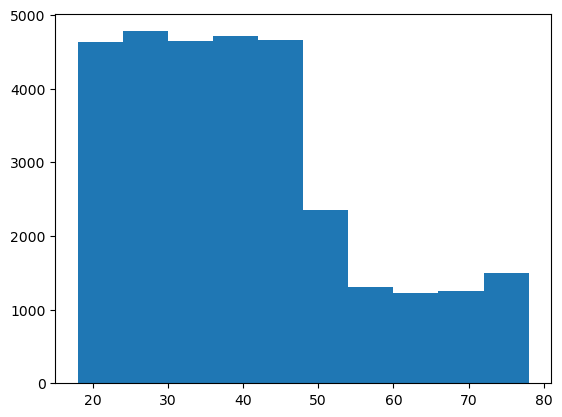

In [6]:
plt.hist(df["Age"])      # histogram               

In [7]:
df["Age"].skew()      # positive skew

0.7291604457646134

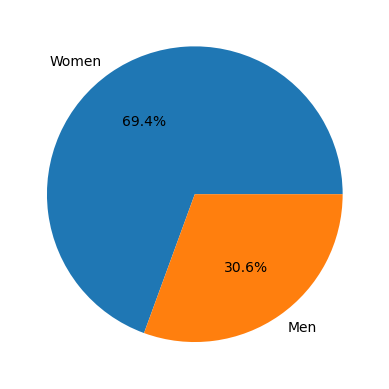

In [8]:
gender=df["Gender"].value_counts()
plt.pie(gender,labels=gender.index,autopct="%1.1f%%")
plt.show()

In [9]:
label_encoder=LabelEncoder()
df["gender_label"]=label_encoder.fit_transform(df["Gender"])
df["gender_label"]

0        1
1        1
2        1
3        1
4        1
        ..
31042    0
31043    0
31044    0
31045    0
31046    0
Name: gender_label, Length: 31047, dtype: int32

In [10]:
df["gender_label"].unique()

array([1, 0])

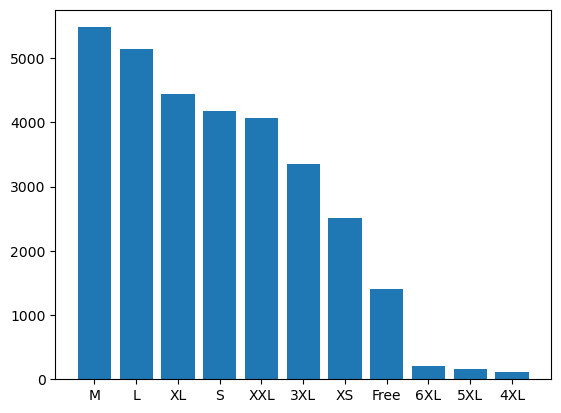

In [11]:
size=df["Size"].value_counts()
plt.bar(size.index,size.values)
plt.show()

In [12]:
from scipy.stats import ttest_ind,ttest_1samp

In [13]:
male_age=df[df['Gender']=='Men']["Age"]
female_age =df[df["Gender"]=="Women"]["Age"]
t_stat,p_val=ttest_ind(male_age,female_age)
print("t-statistic:",t_stat)
print("p_value",p_val)    # age distribution is similar for men and women 

t-statistic: 0.26201378098503364
p_value 0.7933125559203701


In [14]:
print("Men mean age:",male_age.mean())
print("Women mean age:",female_age.mean())           # wich one have highly age distributed

Men mean age: 39.53044027807036
Women mean age: 39.48164988632673


In [15]:
male_amt=df[df["Gender"]=="Men"]["Amount"]
female_amt=df[df["Gender"]=="Women"]["Amount"]
t_stat,p_val=ttest_ind(male_amt,female_amt)
print("t_statistics:",t_stat)
print("p_value:",p_val)           #there is a significant difference between Gender and amount it means men and women are spending more on product

t_statistics: 54.641624219644086
p_value: 0.0


In [16]:
print("Men mean amount:", male_amt.mean())
print("Women mean amount:", female_amt.mean())        #Men spend significantly more on products than Women.

Men mean amount: 801.9384874657678
Women mean amount: 629.2754140954855


In [17]:
from scipy.stats import chi2_contingency

In [18]:
table=pd.crosstab(df["Gender"],df["Size"])
chi2,p,dof,expected=chi2_contingency(table)
print("chi2_square:",chi2)
print("p_value:",p)
table

chi2_square: 248.47894350390786
p_value: 1.1334556572294734e-47


Size,3XL,4XL,5XL,6XL,Free,L,M,S,XL,XS,XXL
Gender,,,,,,,,,,,
Men,1094,3,16,10,292,1577,1767,1351,1306,870,1208
Women,2253,110,145,198,1116,3567,3712,2825,3137,1633,2857


In [19]:
table2=pd.crosstab(df["Gender"],df["Category"])
chi2,p,dof,expected=chi2_contingency(table2)
print("chi2_square:",chi2)
print("p_value:",p)

chi2_square: 12417.426988774592
p_value: 0.0


In [20]:
"""table3=pd.crosstab(df["Gender"],df["Channel"])
chi2,p,dof,expected=chi2_contingency(table3)
print("chi2_square:",chi2)
print("p_value:",p)"""

'table3=pd.crosstab(df["Gender"],df["Channel"])\nchi2,p,dof,expected=chi2_contingency(table3)\nprint("chi2_square:",chi2)\nprint("p_value:",p)'

In [21]:
table4=pd.crosstab(df["Gender"],df["ship-state"])
chi2,p,dof,expected=chi2_contingency(table4)
print("chi_square:",chi2)
print("p_value:",p)                 #there is a significant association between Gender and size

chi_square: 154.97227009018584
p_value: 6.284170999782676e-13


In [22]:
numeric_df=df.select_dtypes(include=["int64"])
num_df=numeric_df.iloc[:,2:-1]
num_df

,Age,Qty,Amount
0,44,1,376
1,29,1,1449
2,67,1,453
3,20,1,729
4,62,1,544
...,...,...,...
31042,60,1,565
31043,34,1,939
31044,29,1,1115
31045,46,1,399


In [23]:
print("correlation_matrix")
num_df.corr()

correlation_matrix


,Age,Qty,Amount
Age,1.000000,0.004884,0.003522
Qty,0.004884,1.000000,0.172377
Amount,0.003522,0.172377,1.000000


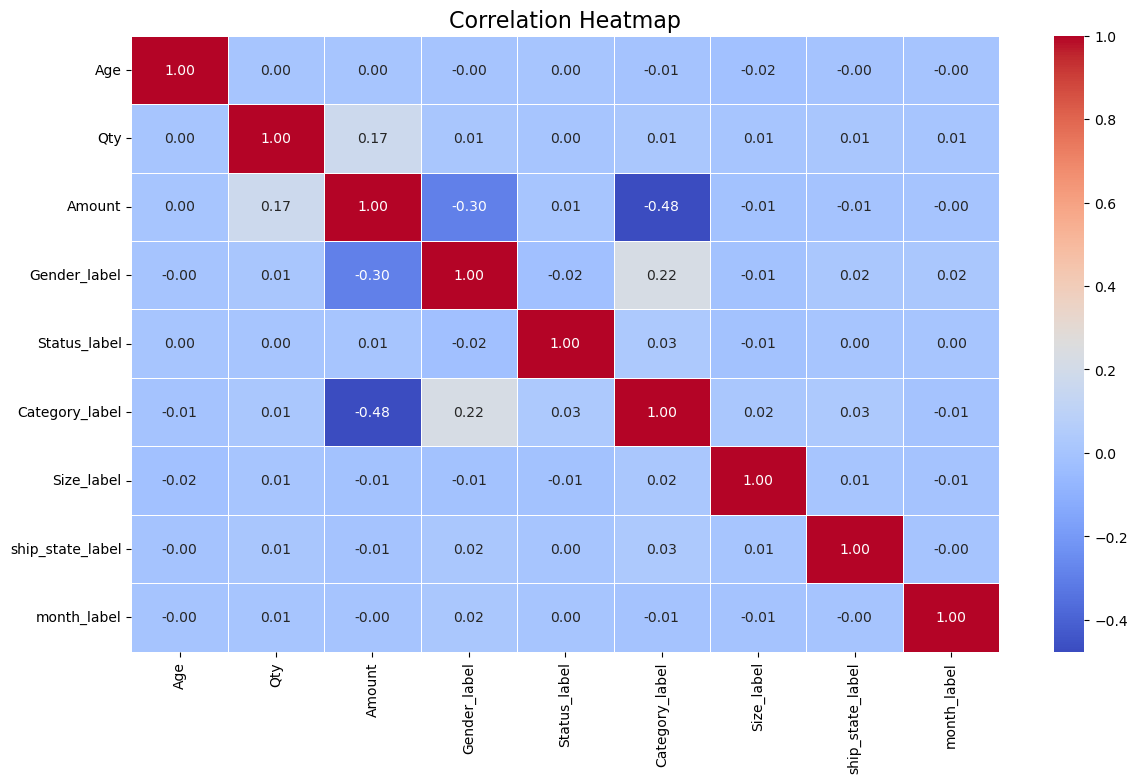

In [24]:
label_encoder=LabelEncoder()
df1=pd.DataFrame()
df1["Age"] = df["Age"]
df1["Qty"] = df["Qty"]
df1["Amount"] = df["Amount"]
df1["Gender_label"]=label_encoder.fit_transform(df["Gender"])
df1["Status_label"]=label_encoder.fit_transform(df["Status"])
df1["Category_label"]=label_encoder.fit_transform(df["Category"])
df1["Size_label"]=label_encoder.fit_transform(df["Size"])
df1["ship_state_label"]=label_encoder.fit_transform(df["ship-state"])
df1["month_label"]=label_encoder.fit_transform(df["month"])
corr = df1.corr()
corr
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Heatmap", fontsize=16)
plt.show()


In [25]:
df1["month_label"].unique()

array([ 2,  9, 10, 11,  1,  5,  6,  8,  0,  7,  3,  4])

In [26]:
"""import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figuresize=(10,6))"""

'import seaborn as sns\nimport matplotlib.pyplot as plt\nplt.figure(figuresize=(10,6))'

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

In [28]:
#df=pd.read_csv("Vrinda_Store_csv.csv")

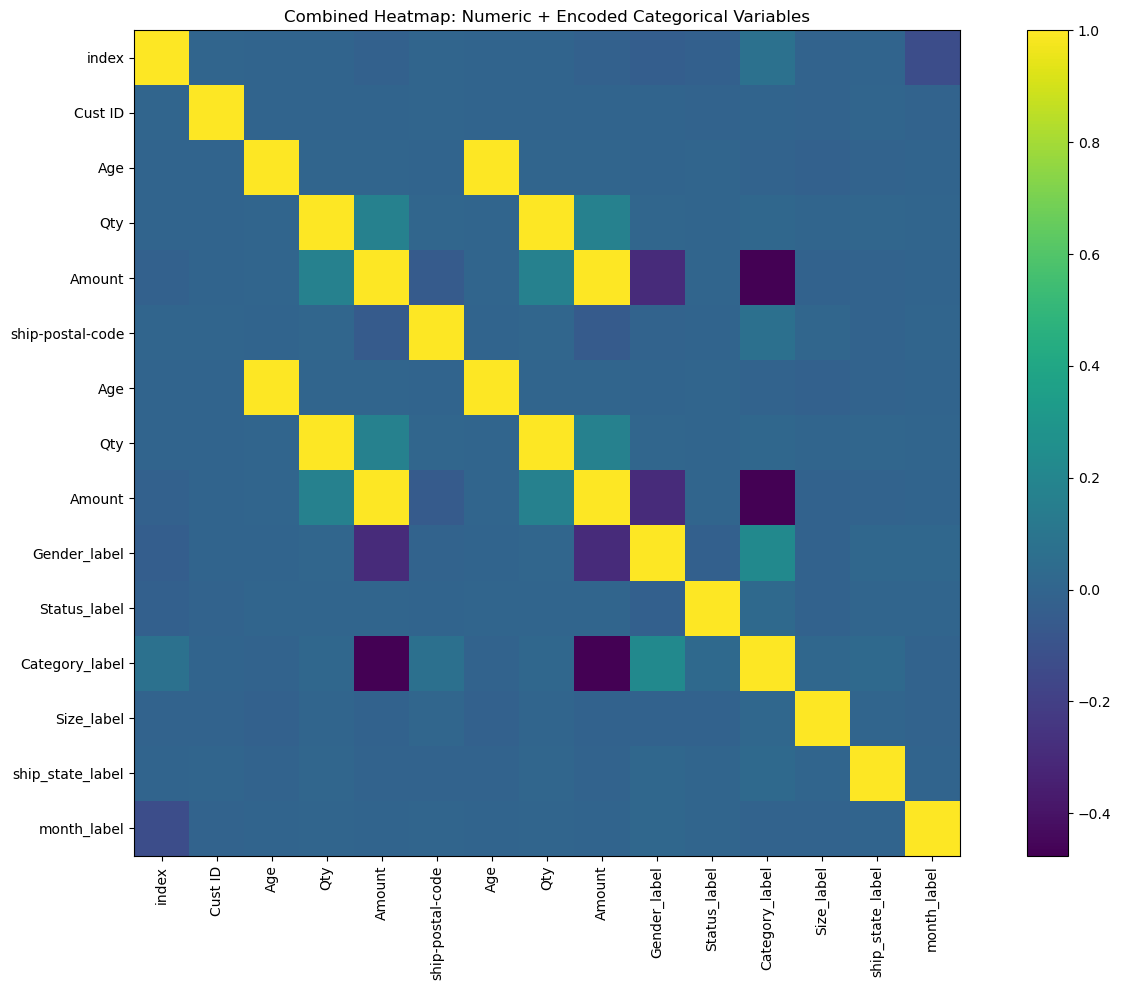

In [29]:
numeric_df = df.select_dtypes(include=["int64","float64"])
combined_df = pd.concat([numeric_df, df1], axis=1)
combined_df.head()
corr_matrix = combined_df.corr()
corr_matrix
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 10))

plt.imshow(corr_matrix)

# Set ticks
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

# Add colorbar
plt.colorbar()

plt.title("Combined Heatmap: Numeric + Encoded Categorical Variables")
plt.tight_layout()
plt.show()


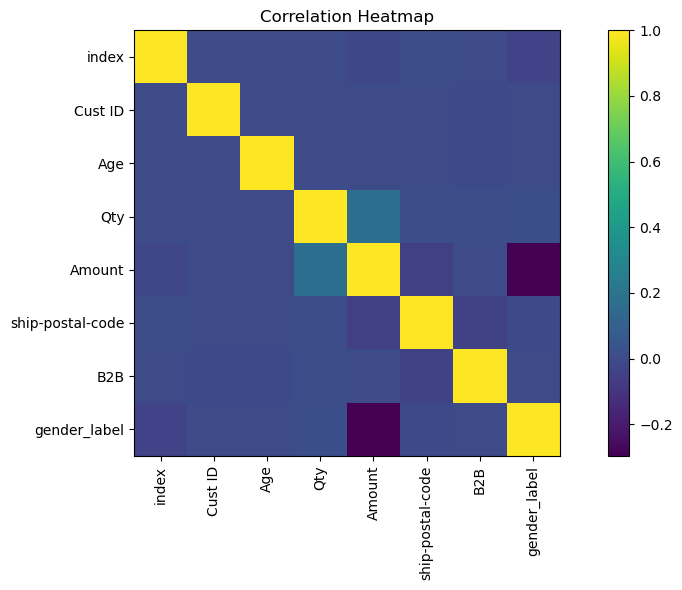

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
#df = pd.read_csv("/mnt/data/Vrinda_Store_csv (2).csv")

# Create correlation matrix
corr = df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(10, 6))
plt.imshow(corr)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar()
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


In [31]:
from scipy.stats import f_oneway               # ANOVA Test group by
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [33]:
groups=[group["Amount"].values for name,group in df.groupby("Category")]
f_value,p_value=f_oneway(*groups)
print("ANOVA Result:")
print("F_statistics:",f_value)                   # one way ANOVA group by
print("p_value:",p_value)                    #There is a highly significant difference in Amount  across different Product Categories.

ANOVA Result:
F_statistics: 2881.437597711236
p_value: 0.0


## LINEAR REGRESSION TEST

In [53]:
label_encoder = LabelEncoder()

df["Gender_label"] = label_encoder.fit_transform(df["Gender"])
df["Category_label"] = label_encoder.fit_transform(df["Category"])
df["Status_label"] = label_encoder.fit_transform(df["Status"])
df["Size_label"] = label_encoder.fit_transform(df["Size"])
df["ship_state_label"] = label_encoder.fit_transform(df["ship-state"])
df["month_label"] = label_encoder.fit_transform(df["month"])

In [52]:
X=df[["Age","Qty","Gender_label","Category_label","Status_label","Size_label","ship_state_label","month_label"]]
Y=df["Amount"]

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.3, random_state=42
)


In [50]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [49]:
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

print("R² (Train):", r2_score(y_train, y_pred_train))
print("R² (Test):", r2_score(y_test, y_pred_test))

R² (Train): 0.30375367754403704
R² (Test): 0.2843754503269903
